# Multiple Variable Linear Regression

In [13]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt

## Training Dataset

Create a small housing-price dataset.

- Each row represents one house.
- Columns represent:
  - Size (sq ft)
  - Number of bedrooms
  - Number of floors
  - Age of house
- `y_train` contains the target house prices.

In [14]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])
X_features = ['size(sqft)','bedrooms','floors','age']

## Compute Cost

Calculate the cost of the current model parameters `w` and `b`.

For each training example:

$$
f_{w,b}(x) = w \cdot x + b
$$

- Compute the prediction.
- Compute the squared error.
- Sum the errors across all training examples.

The cost measures how well the model fits the training data.

In [15]:
def cost_function(X, y, w, b):
    m = X.shape[0]
    cost = 0
    for i in range(m):
        err = ((np.dot(X[i], w) + b) - y[i])**2
        cost += err
    return cost/ (2*m)

## Compute Gradients

Compute the partial derivatives of the cost function with respect to:

- `w` (feature weights)
- `b` (bias)



In [16]:
def compute_gradient(X, y, w, b):
    dj_dw = np.zeros_like(w) # Creates an array of zeros matching the exact shape and data type of 'template_array'
    dj_db = 0
    m,n = X.shape
    
    for i in range(m):
        err = (np.dot(X[i],w)+b - y[i])
        for j in range(n):
            dj_dw[j] += err * X[i, j]
        dj_db += err
    dj_dw = dj_dw/m
    dj_db = dj_db/m
    return dj_dw , dj_db

## Gradient Descent

Iteratively update the model parameters to minimize the cost function.

At each iteration:

1. Compute gradients.

2. Update parameters:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

3. Store the cost for visualization.

The optimization loop is reusable because the cost and gradient functions are passed as arguments.

In [17]:
def gradient_descent(X, y, w_in, b_in,  alpha, num_iters, cost_func, gradient_func ):
    # cost_function and gradient_function are passed as arguments (dependency injection) 
    # to keep this optimization loop reusable for different models (e.g., Linear vs. Logistic)
    j_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw , dj_db = gradient_func(X , y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i<100000:  # prevent resource exhaustion 
            j_history.append(cost_func(X, y, w, b))

        if i% math.ceil(num_iters/10) == 0:
            current_cost = cost_func(X, y, w, b)
            print(f"Iteration {i:4d}: cost {current_cost:8.2f}")

    return w, b, j_history

## Train the Model

Initialize the model parameters and run gradient descent.

- Initialize all weights to zero.
- Initialize the bias to zero.
- Choose a learning rate `alpha`.
- Run gradient descent for a fixed number of iterations.

The optimized parameters are stored in:

- `w_final`
- `b_final`

In [18]:
m,n = X_train.shape 
initial_w = np.zeros(n)
initial_b = 0.
alpha = 5.0e-7
iterations = 1000
w_final, b_final, cost_history = gradient_descent(X_train, y_train, initial_w, initial_b, alpha, iterations, cost_function, compute_gradient)
print(f"Parameters \nw: {w_final}\nb: {b_final}")


Iteration    0: cost  2529.46
Iteration  100: cost   695.99
Iteration  200: cost   694.92
Iteration  300: cost   693.86
Iteration  400: cost   692.81
Iteration  500: cost   691.77
Iteration  600: cost   690.73
Iteration  700: cost   689.71
Iteration  800: cost   688.70
Iteration  900: cost   687.69
Parameters 
w: [ 0.20396569  0.00374919 -0.0112487  -0.0658614 ]
b: -0.002235407530932535


## Make Predictions

Use the learned parameters to predict house prices for the training examples.

Predictions are computed using:

$$
f_{w,b}(x) = w \cdot x + b
$$

Compare the predicted values with the actual target values.

In [19]:

for i in range(m):
    print(f"Prediction:{np.dot(X_train[i], w_final)+b_final}, Target: {y_train[i]}")

Prediction:426.18530497189204, Target: 460
Prediction:286.1674720078562, Target: 232
Prediction:171.46763087132317, Target: 178


## Visualize Cost Reduction

Plot the cost function versus iteration number.

- Left plot: Complete training history.
- Right plot: Later portion of training.

These plots help verify that gradient descent is reducing the cost and converging toward a minimum.

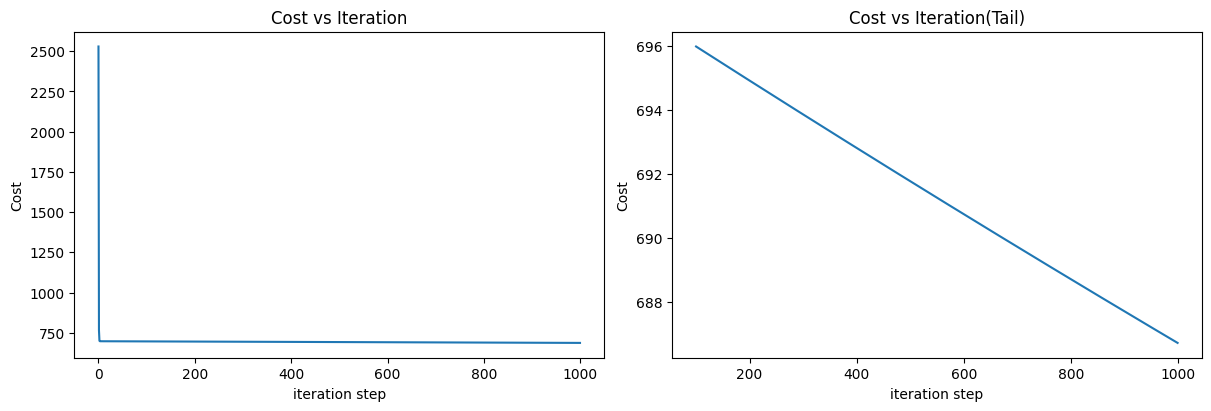

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout = True, figsize=(12, 4))
ax1.plot(cost_history)
ax2.plot(100+np.arange(len(cost_history[100:])),cost_history[100:])
ax1.set_title("Cost vs Iteration"); ax2.set_title("Cost vs Iteration(Tail)")
ax1.set_xlabel('iteration step'); ax2.set_xlabel('iteration step')
ax1.set_ylabel('Cost'); ax2.set_ylabel('Cost')
plt.show()

## Feature Normalisation — Z-Score

Without normalisation, features have very different scales:
- Size: 852–2104
- Bedrooms: 2–5
- Floors: 1–2
- Age: 35–45

This forces a very small learning rate. Z-score normalisation
rescales each feature to have mean=0 and std=1, allowing a
much larger learning rate and faster convergence.

In [21]:
def zscore_normalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = ( X - mu)/ sigma
    return (X_norm, mu, sigma)

## Train with Normalised Features

Same gradient descent function, same structure —
but now running on normalised input with alpha=0.1
instead of 5e-7. Observe how much faster cost drops.

**Implementation Note:** When normalizing the features, it is important
to store the values used for normalization - the mean value and the standard deviation used for the computations. After learning the parameters
from the model, we often want to predict the prices of houses we have not
seen before. Given a new x value (living room area and number of bed-
rooms), we must first normalize x using the mean and standard deviation
that we had previously computed from the training set.


In [22]:
X_norm, X_mean, X_sigma = zscore_normalize(X_train)
m,n = X_train.shape 
initial_w = np.zeros(n)
initial_b = 0.
alpha = 1.0e-1
iterations = 1000
w_norm, b_norm, ncost_history = gradient_descent(X_norm, y_train, initial_w, initial_b, alpha, iterations, cost_function, compute_gradient)
print(f"After normalisation \nw: {w_norm}\nb: {b_norm}")


Iteration    0: cost 37840.46
Iteration  100: cost     0.00
Iteration  200: cost     0.00
Iteration  300: cost     0.00
Iteration  400: cost     0.00
Iteration  500: cost     0.00
Iteration  600: cost     0.00
Iteration  700: cost     0.00
Iteration  800: cost     0.00
Iteration  900: cost     0.00
After normalisation 
w: [ 38.05161505  41.54327451 -30.98894656  36.34177447]
b: 289.9999999999998


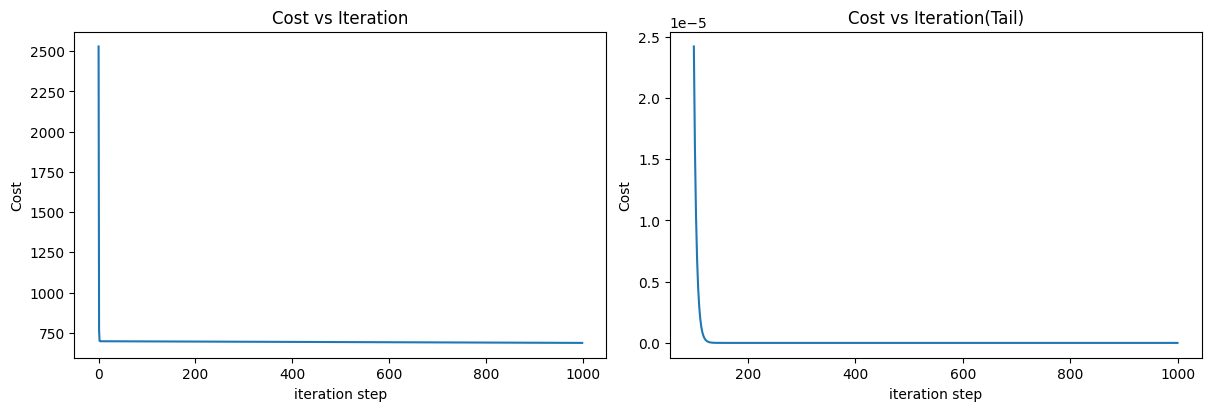

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout = True, figsize=(12, 4))
ax1.plot(cost_history)
ax2.plot(100+np.arange(len(ncost_history[100:])),ncost_history[100:])
ax1.set_title("Cost vs Iteration"); ax2.set_title("Cost vs Iteration(Tail)")
ax1.set_xlabel('iteration step'); ax2.set_xlabel('iteration step')
ax1.set_ylabel('Cost'); ax2.set_ylabel('Cost')
plt.show()

## Visualise Predictions vs Targets per Feature

Each subplot shows one feature against house price.
Orange dots are model predictions, blue are actual targets.
Good fit means orange and blue are close across all features.

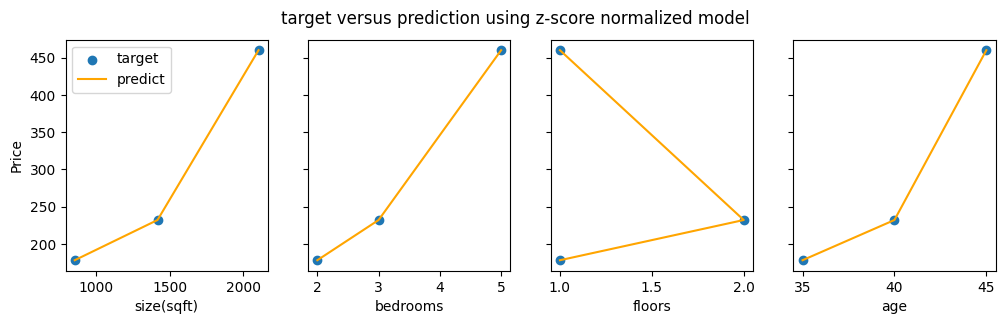

In [24]:
m,n = X_train.shape
yp = np.zeros(m)
for i in range(m):
    yp[i] = np.dot(X_norm[i], w_norm) + b_norm

fig,ax = plt.subplots(1,4, figsize=(12,3), sharey= True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i], y_train, label='target')
    ax[i].set_xlabel(X_features[i])
    ax[i].plot(X_train[:,i], yp, color='orange', label='predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()